In [18]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [166]:
N = 5

# lista = np.array([random.choice([-1, 1]) for n in range(N**2)])
lista = np.array([n+1 for n in range(N**2)])
matriz_lista = lista.reshape(N,N)
matriz_lista

array([[ 1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10],
       [11, 12, 13, 14, 15],
       [16, 17, 18, 19, 20],
       [21, 22, 23, 24, 25]])

In [167]:
def matriz_aumentada(m, N):
    temp_list = []
    temp_list.append(np.concatenate([[red[N-1,N-1]], red[N-1], [red[N-1,0]]]))
    
    for i in range(N):
        temp_list.append(np.concatenate([[red[i,N-1]], red[i], [red[i,0]]]))
    
    temp_list.append(np.concatenate([[red[0,N-1]], red[0], [red[0,0]]]))
    return np.matrix(temp_list)
        
matriz_aumentada(matriz_lista, N)

matrix([[25, 21, 22, 23, 24, 25, 21],
        [ 5,  1,  2,  3,  4,  5,  1],
        [10,  6,  7,  8,  9, 10,  6],
        [15, 11, 12, 13, 14, 15, 11],
        [20, 16, 17, 18, 19, 20, 16],
        [25, 21, 22, 23, 24, 25, 21],
        [ 5,  1,  2,  3,  4,  5,  1]])

In [168]:
def primeros_vecinos(m, N, i, j):
    M_a = matriz_aumentada(m, N) 
    A = (M_a[i-1:i+2, j-1:j+2])
    
    filtro = np.matrix([[1/np.sqrt(2)**3, 1, 1/np.sqrt(2)**3],
                    [1, 0, 1],
                    [1/np.sqrt(2)**3, 1, 1/np.sqrt(2)**3]])
    
    return np.multiply(A,filtro)

# matrix([[0.35355339, 1.        , 0.35355339],
#         [1.        , 0.        , 1.        ],
#         [0.35355339, 1.        , 0.35355339]])

primeros_vecinos(matriz_lista, N, 1, 1)

matrix([[ 8.83883476, 21.        ,  7.77817459],
        [ 5.        ,  0.        ,  2.        ],
        [ 3.53553391,  6.        ,  2.47487373]])

In [169]:
def energia(m, N, i, j):
    vecinos = primeros_vecinos(m, N, i, j)
    E = vecinos * m[i-1,j-1]
    return np.sum(E)

energia(matriz_lista, N, 1, 1)

56.62741699796952

In [172]:
n1 = 10

lista = np.array([random.choice([-1, 1]) for n in range(N**2)])
red = lista.reshape(N,N)
red

array([[ 1, -1, -1,  1,  1, -1, -1, -1,  1, -1],
       [-1, -1,  1,  1,  1,  1,  1,  1, -1, -1],
       [-1, -1, -1,  1, -1, -1, -1, -1, -1,  1],
       [-1,  1, -1,  1,  1,  1, -1,  1,  1,  1],
       [ 1, -1, -1,  1,  1,  1,  1,  1, -1, -1],
       [-1,  1,  1, -1, -1,  1,  1,  1, -1,  1],
       [ 1, -1,  1, -1, -1, -1, -1,  1, -1,  1],
       [ 1,  1, -1,  1, -1, -1,  1,  1, -1,  1],
       [-1, -1,  1,  1,  1,  1, -1,  1,  1,  1],
       [-1,  1,  1,  1, -1,  1, -1, -1,  1, -1]])

In [181]:
energia(red, n1, 1, 1)

-4.707106781186548

In [182]:
def newton(f,df,a,b,epsilon):
    dx=2*epsilon
    contador = 0
    x=0.5*(a+b)
    while dx> epsilon and contador<1000:
        x1=x-f(x)/df(x)
        dx=abs(x-x1)
        x=x1
        contador=contador+1
    return [x,contador]

\begin{equation}\label{eq:1}
    2\tanh^2\left(\frac{2J}{K_BT_c}\right)=1
\end{equation}


Entonces proponemos la función $f(T)$ tal que
\begin{equation}
f(T)=2\tanh^2\left(\frac{2J}{K_BT}\right)-1
\end{equation}

\begin{equation}
\Rightarrow \frac{df(T)}{dT}=\frac{d}{dT}\left(2\tanh^2\left(\frac{2J}{K_BT}\right)-1\right)=-\frac{8J}{T^2K_B}\tanh \left(\frac{2 J}{K_B T}\right)   \text{sech}^2\left(\frac{2 J}{K_B T}\right)
\end{equation}

In [246]:
J = 0.5; K_B=1;
def f(T):
    return 2*(np.tanh(2*J/(K_B*T)))**2-1

def df(T):
    t1 = -8/((T**2)*K_B)
    t2 = np.tanh(2*J/(K_B*T))
    t3 = 1/(np.cosh(2*J/(K_B*T))**2)       
    return t1*t2*t3

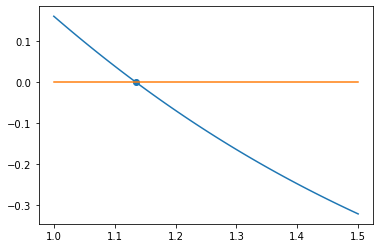

In [255]:
T = np.linspace(1,1.5);
plt.plot(T,f(T))
plt.plot(T,np.zeros(50))
plt.scatter(1.1346900652130067,f(1.1346900652130067))
plt.show()

In [252]:
newton(f,df,1,1.5,1e-4),newton(f,df,1,1.5,1e-5)

([1.1346900652130067, 10], [1.134598744438543, 14])